 Phase 3: Macro-Validation (NHGIS Referee)
 Comparing Probabilistic LED Expected Values against NHGIS Census Records.

In [ ]:
from __future__ import annotations

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)

def normalize_gisjoin(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

In [ ]:
# --- Paths (Adjust as needed) ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"

# Original Spatial LED (To get geometries for the county spatial join)
LED_SPATIAL_PATH = TESTING_SET_PATH / "WA_LED_points-5070.gpkg" 
# The new Probability Engine
LED_ENGINE_PATH = TESTING_SET_PATH / "WA_LED_Monte_Carlo_Engine.parquet"

NHGIS_40_PATH = DATA_PATH / 'NHGIS/nhgis0004_COUNTY_csv/nhgis0004_ds78_1940_county.csv'
NHGIS_TS_PATH = DATA_PATH / 'NHGIS/nhgis0004_COUNTY_csv/nhgis0004_ts_nominal_county.csv'
SHAPE_40_PATH = DATA_PATH / 'NHGIS/nhgis0005_COUNTY_shape/nhgis0005_shapefile_tl2000_us_county_1940.zip'
SHAPE_2020_PATH = DATA_PATH / 'NHGIS/nhgis0005_COUNTY_shape/nhgis0005_shapefile_tl2020_us_county_2020.zip'

# --- 1) Load Data & Reattach Geometry ---
print("1) Loading Data...")
led_spatial = gpd.read_file(LED_SPATIAL_PATH)
led_engine = pd.read_parquet(LED_ENGINE_PATH)

# Merge the probability distribution back onto the spatial dataset.
# Assuming both dataframes have maintained their original alignment/indices or share an ID.
# If they share an exact row order from Script 1, we can join by index. If you have a specific building_id, merge on that.
led_inventory = led_spatial.merge(
    led_engine[['prob_distribution']], 
    left_index=True, right_index=True, how='inner'
)

shape_40 = gpd.read_file(SHAPE_40_PATH)
shape_data = gpd.read_file(SHAPE_2020_PATH)
nhgis_40 = pd.read_csv(NHGIS_40_PATH, encoding="iso-8859-1")
nhgis_data = pd.read_csv(NHGIS_TS_PATH, encoding="iso-8859-1")

# Clean up GISJOIN columns
for df in [nhgis_data, nhgis_40]:
    if "NHGISCODE" in df.columns and "GISJOIN" not in df.columns:
        df.rename(columns={"NHGISCODE": "GISJOIN"}, inplace=True)
    df["GISJOIN"] = normalize_gisjoin(df["GISJOIN"])

shape_40["GISJOIN"] = normalize_gisjoin(shape_40["GISJOIN"])
shape_data["GISJOIN"] = normalize_gisjoin(shape_data["GISJOIN"])

1) Loading Data...


In [ ]:
# --- 2) Spatial Joins ---
print("2) Running Spatial Joins to Counties...")
target_crs = led_inventory.crs
shape_40 = shape_40.to_crs(target_crs)
shape_data = shape_data.to_crs(target_crs)

shape_40_join = shape_40[["GISJOIN", "geometry"]].rename(columns={"GISJOIN": "GISJOIN_40"})
shape_data_join = shape_data[["GISJOIN", "geometry"]].rename(columns={"GISJOIN": "GISJOIN_2020"})

led_joined = gpd.sjoin(led_inventory, shape_40_join, how="inner", predicate="intersects").drop(columns=["index_right"], errors="ignore")
led_joined = gpd.sjoin(led_joined, shape_data_join, how="inner", predicate="intersects").drop(columns=["index_right"], errors="ignore")

2) Running Spatial Joins to Counties...


In [ ]:
# --- 3) Calculate Probabilistic Expected Values ---
print("3) Calculating Expected Cumulative Values...")
# Convert the column of probability arrays into a massive 2D matrix
prob_matrix = np.stack(led_joined['prob_distribution'].values)

# Array indices corresponding to the end of the target decades
# [1920=0, 1925=1, 1930=2, 1935=3, 1940=4 ... 1970=10 ... 2020=20]
led_joined['exp_cum_1940'] = np.sum(prob_matrix[:, :5], axis=1)
led_joined['exp_cum_1970'] = np.sum(prob_matrix[:, :11], axis=1)
led_joined['exp_cum_1980'] = np.sum(prob_matrix[:, :13], axis=1)
led_joined['exp_cum_1990'] = np.sum(prob_matrix[:, :15], axis=1)
led_joined['exp_cum_2000'] = np.sum(prob_matrix[:, :17], axis=1)
led_joined['exp_cum_2010'] = np.sum(prob_matrix[:, :19], axis=1)
led_joined['exp_cum_2020'] = np.sum(prob_matrix[:, :21], axis=1)

3) Calculating Expected Cumulative Values...


In [ ]:
# --- 4) Aggregate to County Level & Merge with NHGIS ---
print("4) Filtering, Aggregating and Merging with NHGIS...")

# Get the exact list of counties we actually have LED data for (e.g., just WA counties)
valid_gisjoins_40 = led_joined["GISJOIN_40"].unique()
valid_gisjoins_2020 = led_joined["GISJOIN_2020"].unique()

# Filter the national census data down to just our target state/counties
nhgis_40 = nhgis_40[nhgis_40["GISJOIN"].isin(valid_gisjoins_40)].copy()
nhgis_data = nhgis_data[nhgis_data["GISJOIN"].isin(valid_gisjoins_2020)].copy()

# 1940 Aggregation
led_1940_county = led_joined.groupby("GISJOIN_40", as_index=False)['exp_cum_1940'].sum()
led_1940_county.rename(columns={"GISJOIN_40": "GISJOIN"}, inplace=True)

# Use a left merge to keep all target counties, even if LED counts are 0
nhgis_40 = nhgis_40.merge(led_1940_county, on="GISJOIN", how="left")
nhgis_40["exp_cum_1940"] = nhgis_40["exp_cum_1940"].fillna(0)

# 1970 - 2020 Aggregation
target_decades = [1970, 1980, 1990, 2000, 2010, 2020]
agg_dict = {f'exp_cum_{d}': 'sum' for d in target_decades}

led_modern_county = led_joined.groupby("GISJOIN_2020", as_index=False).agg(agg_dict)
led_modern_county.rename(columns={"GISJOIN_2020": "GISJOIN"}, inplace=True)

nhgis_data = nhgis_data.merge(led_modern_county, on="GISJOIN", how="left")
for d in target_decades:
    nhgis_data[f"exp_cum_{d}"] = nhgis_data[f"exp_cum_{d}"].fillna(0)

print(f"Filtered to {len(nhgis_data)} counties. Merged output tables ready.")

4) Filtering, Aggregating and Merging with NHGIS...
Filtered to 41 counties. Merged output tables ready.


5) Generating Visualizations...

County-level metrics by decade:
   decade  n_counties     mean_diff      corr
0    1940          40 -11527.853575  0.974899
1    1970          41 -10637.645761  0.993411
2    1980          41  -9519.636399  0.995160
3    1990          41  -5974.227207  0.993310
4    2000          41  -3065.076096  0.989687
5    2010          41  -5730.167474  0.987489
6    2020          41 -10520.975610  0.984567


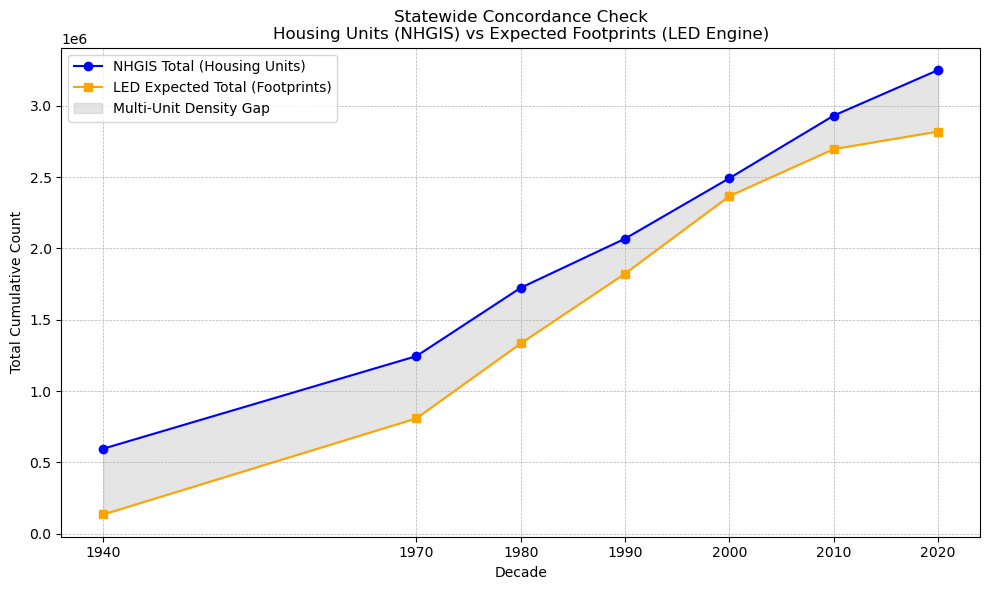

In [ ]:
# --- 5) Plotting & Metrics ---
print("5) Generating Visualizations...")

decade_sources = {
    1940: (nhgis_40, "BXR001", "exp_cum_1940"),
    1970: (nhgis_data, "A41AA1970", "exp_cum_1970"),
    1980: (nhgis_data, "A41AA1980", "exp_cum_1980"),
    1990: (nhgis_data, "A41AA1990", "exp_cum_1990"),
    2000: (nhgis_data, "A41AA2000", "exp_cum_2000"),
    2010: (nhgis_data, "A41AA2010", "exp_cum_2010"),
    2020: (nhgis_data, "A41AA2020", "exp_cum_2020"),
}

def resolve_column(df: pd.DataFrame, base_col: str) -> str | None:
    if base_col in df.columns: return base_col
    for suffix in ("_y", "_x"):
        if f"{base_col}{suffix}" in df.columns: return f"{base_col}{suffix}"
    return None

decade_plot_data = {}
metrics_rows = []

for decade, (src_df, nhgis_col, led_col) in decade_sources.items():
    nhgis_col_resolved = resolve_column(src_df, nhgis_col)
    led_col_resolved = resolve_column(src_df, led_col)
    if not nhgis_col_resolved or not led_col_resolved: continue

    plot_df = src_df[["GISJOIN", nhgis_col_resolved, led_col_resolved]].copy()
    plot_df[nhgis_col_resolved] = pd.to_numeric(plot_df[nhgis_col_resolved], errors="coerce")
    plot_df = plot_df.dropna(subset=[nhgis_col_resolved, led_col_resolved])

    plot_df.rename(columns={nhgis_col_resolved: "nhgis_count", led_col_resolved: "expected_led"}, inplace=True)
    
    # Error Diff: Expected Footprints - Housing Units
    # We expect this to be largely NEGATIVE in urban areas (fewer footprints than housing units)
    plot_df["error_diff"] = plot_df["expected_led"] - plot_df["nhgis_count"] 
    decade_plot_data[decade] = plot_df

    y_true = plot_df["nhgis_count"].to_numpy(dtype=float)
    y_pred = plot_df["expected_led"].to_numpy(dtype=float)
    
    metrics_rows.append({
        "decade": decade,
        "n_counties": len(plot_df),
        "mean_diff": float(np.mean(plot_df["error_diff"])),
        "corr": float(np.corrcoef(y_true, y_pred)[0, 1]) if len(plot_df) > 1 else np.nan
    })

metrics_by_decade = pd.DataFrame(metrics_rows)
print("\nCounty-level metrics by decade:")
print(metrics_by_decade)

# Plotting the Statewide Totals
state_plot_data = []
for decade, plot_df in decade_plot_data.items():
    state_plot_data.append({
        "decade": decade, 
        "total_nhgis": plot_df["nhgis_count"].sum(), 
        "expected_led": plot_df["expected_led"].sum()
    })
    
state_plot_df = pd.DataFrame(state_plot_data).sort_values("decade")

plt.figure(figsize=(10, 6))
plt.plot(state_plot_df["decade"], state_plot_df["total_nhgis"], marker="o", label="NHGIS Total (Housing Units)", color="blue")
plt.plot(state_plot_df["decade"], state_plot_df["expected_led"], marker="s", label="LED Expected Total (Footprints)", color="orange")

# Fill the gap to visualize the density discrepancy
plt.fill_between(state_plot_df["decade"], state_plot_df["total_nhgis"], state_plot_df["expected_led"], color='gray', alpha=0.2, label='Multi-Unit Density Gap')

plt.title(f"Statewide Concordance Check\nHousing Units (NHGIS) vs Expected Footprints (LED Engine)")
plt.xlabel("Decade")
plt.ylabel("Total Cumulative Count")
plt.xticks(state_plot_df["decade"])
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()